![parabola-banner](../assets/images/parabola-parable-banner.png)

Recently I was working on a translation project to turn a bunch of old lecture notes into a [quarto book](https://quarto.org/). The project has been really fun and hopefully one day it will be complete. What I have finished so far can be found [here](https://eitanlees.github.io/comphys/).

During the project I came across this figure.

<img src="../assets/images/gray-parabola.png" alt="drawing" width="500"/>

A parabola used as an example to explain minimization methods. 

Fine enough in the context but for this project I want to create a full reproduction of the source material and that meant recreating all of the figures. 

This was a challenge as I did not have any of the source code, only the PDFs I had saved many years ago.

## An Initial Guess

I decided to just eyeball it! You only need three points to define a parabola. More generally you need $N+1$ points to exactly define an $N^{th}$ order polynomial. A parabola is a second order polynomial so three points will do. Two roots and the minimum seemed like good points to estimate

In this specific example it looks like one of the roots is exactly at $-1$ so that just leaves two more points to me to guess. 

I went with $x = 2.2$ for the other root and $(0.8, -2.5)$ for the minimum.

but three points are not a parabola. At least not yet! How do I take these three points and figure out the coefficients of a parabola?

This sounds like a high school algebra question. I didn't want to fuss with all of the algebra. Also I am not in high school any more!

## Points to Polynomials

I remembered doing something like this before. We start with a set of points
$$
\begin{aligned}
p_1 &= (x_1,\;  y_1) = (-1.0,\; 0.0) \\
p_2 &= (x_2,\;  y_2) = (0.8,\; -2.5) \\
p_3 &= (x_3,\;  y_3) = (2.2,\; 0.0)
\end{aligned}
$$

but really we want a function $f(x)$ which when we input our specific $x$'s we get our specific $y$'s

What we want is 

$$
\begin{aligned}
f(-1.0) &= 0.0 \\
f(0.8) &= -2.5 \\
f(2.2) &= 0.0
\end{aligned}
$$

The functional form we are aiming for is the quadratic equation

$$ f(x) = ax^2 + bx + c$$

but we don't know $a$, $b$, or $c$. 


To find them we can substitute $x$ and $y$ into the quadratic equation for each point

$$
\begin{aligned}
a (x_1)^2 + b x_1 + c &= y_1 \\
a (x_2)^2 + b x_2 + c &= y_2 \\
a (x_3)^2 + b x_3 + c &= y_3
\end{aligned}
$$

if you look closely at this system of equations you can rewrite it in matrix form as  

$$
\begin{bmatrix}
(x_1)^2 & x_1 & 1 \\
(x_2)^2 & x_2 & 1 \\
(x_3)^2 & x_3 & 1
\end{bmatrix}
\begin{bmatrix}
a \\ b \\ c
\end{bmatrix}
=
\begin{bmatrix}
y_1 \\ y_2 \\ y_3
\end{bmatrix}
$$

This form should be familiar. You have a matrix and some unknown stuff on the right hand side along with some known stuff on the left hand side. 

$$
Ax=b
$$

This standard form is known as _The Matrix Equation_. Solving this simple looking little equation is the subject of entire courses. Whole books have been written about this equation. Unknown numbers of Linear Algebra students have spent countless hours toiling away to solve this equation.

The solution is also a simple looking little equation

$$
x=A^{-1}b
$$

Where $A^{-1}$ is the inverse of the original matrix $A$. Getting there is the hard part. I was told in graduate school to "never invert the matrix". It's a trap! In practice you don't compute the inverse explicitly. Instead the system can be solved by other means. Not all matricies are created equal either. Some have properties that make them very difficult to invert and sometimes it is even impossible. Getting to know matrices and their properties is a major topic for students of Linear Algebra.

### A Special Matrix
Our particular matrix of interest has a special name.

$$
\begin{bmatrix}
(x_1)^2 & x_1 & 1 \\
(x_2)^2 & x_2 & 1 \\
(x_3)^2 & x_3 & 1
\end{bmatrix}
$$

It is called the _[Vandermonde Matrix](https://en.wikipedia.org/wiki/Vandermonde_matrix)_. 

In general if you had $m$ points and a polynomial of order $n$ then Vandermonde Matrix would look like

$$
V(x_0, x_1, \dots, x_m) =
\begin{pmatrix}
x_0^n & \dots & x_0^2 & x_0 & 1 \\
x_1^n & \dots & x_1^2 & x_1 & 1 \\
x_2^n & \dots & x_2^2 & x_2 & 1 \\
\vdots & \ddots & \vdots & \vdots & \vdots \\
x_m^n & \dots & x_m^2 & x_m & 1
\end{pmatrix}
$$

Unfortunately this matrix has terrible properties. Vandermonde matrices are ill-conditioned, sensitive to noise and generally numerically unstable. For high-degree polynomials things get worse.

> In numerical analysis, solving the equation $Va=y$ naïvely by Gaussian elimination results in an algorithm with time complexity $\mathcal{O}(n^3)$ 

Ugh, nobody has time for cubic complexity. Bleh!

There are techniques which are less _naïve_ which can get better results but I won't go into them here. 

## Initial Polynomial Fit

How have we gotten this far and not seen a single line of code! 

Let's do this. Let's take three points, build a Vandermonde Matrix, and solve the matrix equation. Numpy to the rescue!

In [ ]:
import numpy as np

x = np.array([-1, 0.8, 2.2])
y = np.array([0, -2.5, 0])
A = np.column_stack([x**2, x, np.ones(x.shape[0])])
a, b, c = np.linalg.solve(A, y)

print(f"f(x) = {a:.3}·x² + {b:.3}·x + {c:.3}")

f(x) = 0.992·x² + -1.19·x + -2.18


That was pretty easy! It turns out that numpy has a method for creating the Vandermonde matrix as well

In [ ]:
np.vander(x)

array([[ 1.  , -1.  ,  1.  ],
       [ 0.64,  0.8 ,  1.  ],
       [ 4.84,  2.2 ,  1.  ]])

So we could have done it all in one shot like this

In [ ]:
np.linalg.solve(np.vander(x), y)

array([ 0.99206349, -1.19047619, -2.18253968])

Instead of building the matrix equation from scratch and using `np.linalg.solve` directly, 
we could leverage the nice polynomial library I discovered recently to immediately fit a second order polynomial to our data

In [ ]:
p = np.polynomial.Polynomial.fit(x, y, 2)
p.convert()

Polynomial([-2.18253968, -1.19047619,  0.99206349], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Remember the `np.polynomial` methods assume the coefficients are sorted from lowest to highest order. 

### Aside: How Numpy Does It

I really like the `np.polynomial` module. I was interested in what exactly is going on when we call the `fit` method. I wanted to see if my approach was similar or if the Numpy developers knew something I did not. A less _naïve_ approach :P

I did what [Oz](https://ozwrites.com/) would do and jumped into the Numpy source code. 

It's a little bit confusing and a bit of a distraction from the task at hand but lets take a short trip down the Numpy rabbit hole:

We call the `fit` of the `Polynomial` class. This method is defined in the `numpy/numpy/polynomial
/_polybase.py` file as 

```python
 @classmethod
    def fit(cls, x, y, deg, domain=None, rcond=None, full=False, w=None,
        window=None, symbol='x'):
        # ...
        xnew = pu.mapdomain(x, domain, window)
        res = cls._fit(xnew, y, deg, w=w, rcond=rcond, full=full)
        # ...
        
```

It seems this method is a thin wrapper around a call to the the `_fit` class method but ...

```python
    @staticmethod
    @abc.abstractmethod
    def _fit(x, y, deg, rcond, full):
        pass
```

.. this method is undefined! Surprise!

It turns out that `fit` is actually part of the _Abstract Base Class_ that the other polynomial classes inherit. I still don't really have a good handle on proper Object Oriented Programming design and I have never used an _Abstract Base Class_ in my own work. 

The trail picks back up in `numpy/polynomial/polynomial.py` with the the `Polynomial` class

```python
class Polynomial(ABCPolyBase):
    # ...
    _fit = staticmethod(polyfit)
    # ...
```

Here we find that `_fit` is really an alias for the `polyfit` method. 

```python
from . import polyutils as pu

def polyfit(x, y, deg, rcond=None, full=False, w=None):
    return pu._fit(polyvander, x, y, deg, rcond, full, w)
```

which is really a call to the `_fit` method from the `polyutils` module. Phew! I am getting a workout jumping all around. 

Almost done I promise, but first a quick aside to figure out the definition of `polyvander` before we dive into the `pu._fit` method from `polyutils`. 

```python
def polyvander(x, deg):
        // ...
        v[1] = x
        for i in range(2, ideg + 1):
            v[i] = v[i - 1] * x
    return np.moveaxis(v, 0, -1)
```

That name should be familiar if you remember our matrix shenanigans from earlier. This is the first place we are starting to see a connection to our previous work.

Now off to the `polyutils` methods in `numpy/polynomial/polyutils.py`

```python
def _fit(vander_f, x, y, deg, rcond=None, full=False, w=None):
    # ...
    van = vander_f(x, lmax)[:, deg]

    # set up the least squares matrices in transposed form
    lhs = van.T
    rhs = y.T

    # Solve the least squares problem.
    c, resids, rank, s = np.linalg.lstsq(lhs.T / scl, rhs.T, rcond)
    c = (c.T / scl).T
    # ...
    return c
```

Alright! now I think we have bottomed out and actually found _where_ the fit is happening. 

I was close! I didn't do any scaling and I used `solve` instead of `lstsq` but otherwise we are doing pretty much the same thing. I am not sure what is going on with all of the transposing but I will leave that as an exercise to the reader :wink:

The key idea is that NumPy builds a Vandermonde matrix and solves a least-squares problem using `lstsq`

Interestingly in the [`solve` documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) they mention that you should use `lstsq` in certain cases: 

> $a$ must be square and of full-rank, i.e., all rows (or, equivalently, columns) must be linearly independent; if either is not true, use `lstsq` for the least-squares best “solution” of the system/equation.

#### Read The Docs

Numpy has excellent documentation. I recommend reading the docs more thoroughly than just for reference. They are a treasure trove of scientific computing insight and learnings.  

In the `solve` docs there is a pleasent reference to Gibert Strang as well which I was able to dig up

> G. Strang, Linear Algebra and Its Applications, 2nd Ed., Orlando, FL, Academic Press, Inc., 1980, pg. 22.

<img src="../assets/images/strang-ref.png" alt="drawing" width="500"/>

and there it is again $Ax=b$. This equation, along with the eigen equation $Ax=\lambda x$, are at the heart of Linear Algebra. 

[Gilbert Strang](https://en.wikipedia.org/wiki/Gilbert_Strang) is a cool dude and if you are studying Linear Algebra his lectures are excellent and timeless. I met him once during my time at FSU. 

## Plot Replication

Alright, back to the program! I have lost the plot a little bit. We were trying to create a plot from some old notes and got lost in Linear Algebra world. Sorry not sorry!

So now we have a polynomial, lets plot it!

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [ ]:
import matplotlib.pyplot as plt

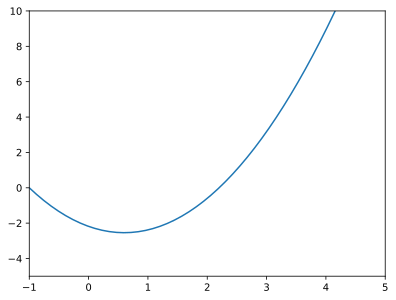

In [ ]:
fig, ax = plt.subplots()
xlim, ylim = (-1, 5), (-5, 10)
x = np.linspace(*xlim)

ax.plot(x, p(x))
ax.set(xlim=xlim, ylim=ylim);

This is fine, but it doesn't _look_ like the original plot.

Lets take a closer look at the original

<img src="../assets/images/gray-parabola-with-labels.png" alt="drawing" width="500"/>

Here are some of my initial take aways

1. In general the figure is black and white with pretty thin lines. 
2. The axis limits are asymmetric and have a different number of labels. The axis spines have been moved to align with the zero reference point. The axis line can be seen under the zero label.
4. I am unsure about the font, but maybe Helvetica.
5. The top and right spines have been removed completely.

Let's give it a shot

In [ ]:
w = 6.4
xlim, ylim = (-1, 5), (-5, 10)

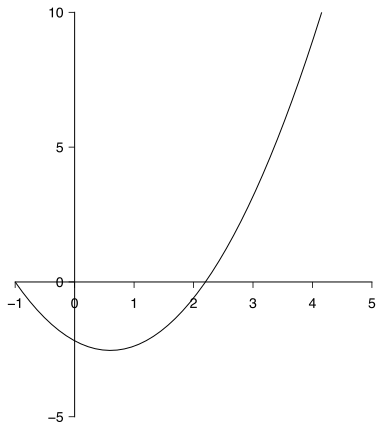

In [ ]:
fig, ax = plt.subplots(figsize=(w , w*1.141))

x = np.linspace(*xlim)

ax.plot(x, p(x), 'k', lw=1)

# === Style Spines ===
for spine in ["left", "bottom"]:
    ax.spines[spine].set(position='zero', linewidth=1)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# === Style Ticks ===
ax.tick_params(length=6, labelsize=14) # To my eye the ticks are a bit longer
ax.tick_params(axis='x',pad=10) # I think there is slightly different padding
ax.tick_params(axis='y',pad=5)  # on the x and y axis
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Helvetica")
ax.set_xticks(np.arange(-1, 6))
ax.set_yticks(np.arange(-5, 11, 5))

ax.set(xlim=xlim, ylim=ylim);

Pretty good so far!

I want to pause to extract some of the style into a separate style file to easily apply elsewhere. 

```
axes.spines.top: False
axes.spines.right: False
axes.labelsize : 14

xtick.major.size: 6
ytick.major.size: 6
xtick.major.pad: 10
ytick.major.pad: 5
xtick.labelsize: 14
ytick.labelsize: 14

font.family: sans-serif
font.sans-serif: Helvetica
font.size : 14
```

Now we can set these styles to be shared across the session

In [ ]:
plt.style.use('gray.mplstyle')

and this cleans up the plot a little bit. Not everything has been swept under the rug, but some of the styling is out of the way 

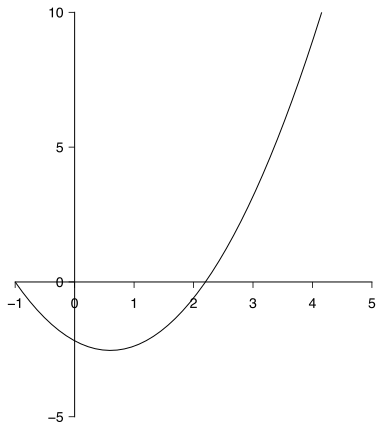

In [ ]:
fig, ax = plt.subplots(figsize=(w , w*1.141))
x = np.linspace(*xlim)
ax.plot(x, p(x), 'k', lw=1)

# === Spines ===
for spine in ["left", "bottom"]:
    ax.spines[spine].set(position='zero', linewidth=1)

# === Ticks ===
ax.set_xticks(np.arange(-1, 6))
ax.set_yticks(np.arange(-5, 11, 5))

ax.set(xlim=xlim, ylim=ylim);

## Plot Digitization

Now comes the question of those pesky points. Where exactly do they lay on the parabola? I could guess but I wanted a more accurate method to find out where exactly these points were. This lead me into the world of plot digitization where one uploads an image, selects some reference points to define an axis and is then able to convert other selections into the correct data coordinates. Initially I considered writing a tool myself, but I figured there must be something out there for this problem. I landed on using the [WebPlotDigitizer](https://automeris.io/) and was very impressed. 

First you upload your image and manually assign the axis refernece points

<img src="../assets/images/WPD-Axis.png" alt="drawing" width="500"/>

With the axis selected then I could select markers for the reference points and export the data

<img src="../assets/images/WPD-Points.png" alt="drawing" width="500"/>

In [ ]:
points = np.loadtxt('../assets/data/gray-points.csv', delimiter=',')
points[:, 0], points[:, 1]

(array([-0.50742699,  1.24736513,  2.9977953 ]),
 array([-1.34544672, -2.12824868,  3.20619729]))

This is very revealing! If you look at the x points they are very close to $[-0.5,\; 1.25,\; 3.0]$, which were probably the actual numbers used. There is always a bit of error when doing plot digitization, both on the axis selection and the point selection. There is an [interesting talk](https://youtu.be/QaS49WQsXd4?si=4YzgBVtr83Ejh_bC) from the creator of WebPlotDigitizer I recommend watching if you are interested in learning more. I found the tool a bit confusing to use, and it was helpful to see it in action. I feel like this tool will be very useful in the future for all sorts of projects, particularly with historical plots. I would imagine having some fun pulling the raw data off of famous old plots and modernizing them.

With these points we can finish off our plot

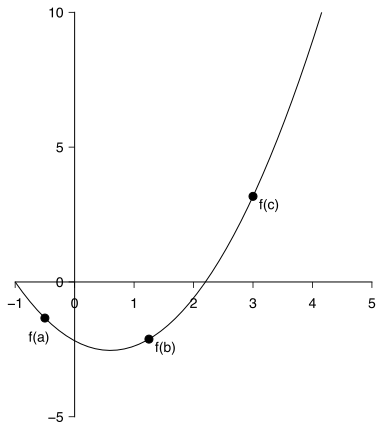

In [ ]:
w, xlim, ylim = 6.4, (-1, 5), (-5, 10)
fig, ax = plt.subplots(figsize=(w , w*1.141))
x = np.linspace(*xlim)
xp = [-0.5, 1.25, 3.0]
yp = p(xp)
ax.plot(x, p(x), 'k', lw=1)
ax.plot(xp, yp, 'ko', markersize=8)

# === Labels ===
dx = 0.1
labels = [
    ('f(a)', xp[0]-dx, yp[0]-5*dx, 'top', 'center'),
    ('f(b)', xp[1]+dx, yp[1]-dx,   'top', 'left'),
    ('f(c)', xp[2]+dx, yp[2]-dx,   'top', 'left'),
]
for text, x, y, va, ha in labels:
    ax.text(x, y, text, va=va, ha=ha)

# === Spines ===
for spine in ["left", "bottom"]:
    ax.spines[spine].set(position='zero', linewidth=1)

# === Ticks ===
ax.set_xticks(np.arange(-1, 6))
ax.set_yticks(np.arange(-5, 11, 5))

ax.set(xlim=xlim, ylim=ylim);

Now that's what I call a plot! Pretty close to the original. 

That got me thinking, when I initially fit the parabola I was working off of guesses for the roots and the minimum. 
Now I could instead use the plot digitization tool to extract many points along the line and use those to fit instead. 

Again WebPlotDigitizer to the rescue!

<img src="../assets/images/WPD-Line.png" alt="drawing" width="500"/>

In [ ]:
points = np.loadtxt('../assets/data/gray-line.csv', delimiter=',')
points[:10]

array([[ 0.1       , -2.3080876 ],
       [ 0.2       , -2.39915211],
       [ 0.3       , -2.46625227],
       [ 0.4       , -2.5237667 ],
       [ 0.5       , -2.54293818],
       [ 0.6       , -2.55731678],
       [ 0.7       , -2.53814531],
       [ 0.8       , -2.51897383],
       [ 0.9       , -2.45666653],
       [ 1.        , -2.39435924]])

Now I have many points along the curve. I can fit it and then compare to my original polynomial.

In [ ]:
p_new = np.polynomial.Polynomial.fit(*points.T, 2)
p_new.convert()

Polynomial([-2.20337043, -1.18310027,  0.99668055], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

and as reference here was the original polynomial

In [ ]:
p.convert()

Polynomial([-2.18253968, -1.19047619,  0.99206349], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

We can calculate the relative error between these two estimates.

In [ ]:
c = p.convert().coef
c_new = p_new.convert().coef
relative_error = np.abs(c - c_new) / np.abs(c_new)
relative_error

array([0.00945404, 0.0062344 , 0.00463243])

Pretty close. All within 1%. 

With this new fitted polynomial it got me thinking I could start with `p_new` and ask what are the roots and minima instead

As a reference, remember when I started down this rabbit hole I estimated the roots at $-1.0$ and $2.2$. The $x$ location of the minimum was harder to estimate and initially I went with $0.8$. 

Now we can check

In [ ]:
p_new.roots()

array([-1.00740916,  2.19444975])

In [ ]:
p_new.deriv().roots()

array([0.5935203])

Not bad, but that means we can now make the plot again with `p_new` instead

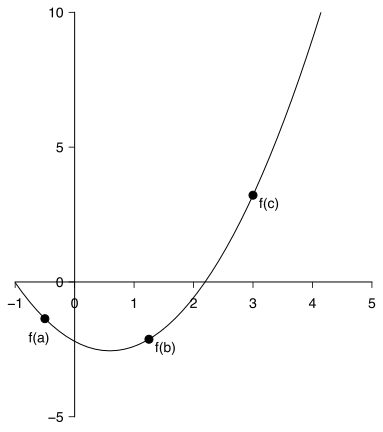

In [ ]:
w, xlim, ylim = 6.4, (-1, 5), (-5, 10)
fig, ax = plt.subplots(figsize=(w , w*1.141))
x = np.linspace(*xlim)
xp = [-0.5, 1.25, 3.0]
yp = p_new(xp)
ax.plot(x, p_new(x), 'k', lw=1)
ax.plot(xp, yp, 'ko', markersize=8)

# === Labels ===
dx = 0.1
labels = [
    ('f(a)', xp[0]-dx, yp[0]-5*dx, 'top', 'center'),
    ('f(b)', xp[1]+dx, yp[1]-dx,   'top', 'left'),
    ('f(c)', xp[2]+dx, yp[2]-dx,   'top', 'left'),
]
for text, x, y, va, ha in labels:
    ax.text(x, y, text, va=va, ha=ha)

# === Spines ===
for spine in ["left", "bottom"]:
    ax.spines[spine].set(position='zero', linewidth=1)

# === Ticks ===
ax.set_xticks(np.arange(-1, 6))
ax.set_yticks(np.arange(-5, 11, 5))

ax.set(xlim=xlim, ylim=ylim);

Ok ok, phew! All done now ... but wait!

I am not satisfied with these coefficients. Something seems off. 

In [ ]:
c_new

array([-2.20337043, -1.18310027,  0.99668055])

Too many decimals. I bet when Dr.Gray created this figure he didn't type all of those decimals. It was probably something more like 

In [ ]:
p_gray = np.polynomial.Polynomial([-2.2, -1.2, 1])
print(f"Roots: {p_gray.roots()}")
print(f"Minimum: {p_gray.deriv().roots()}")
print('-'*50)
p_gray

Roots: [-1.   2.2]
Minimum: [0.6]
--------------------------------------------------


Polynomial([-2.2, -1.2,  1. ], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

That feels tighter and more realistic as to the formula that was actually used. 

$$
f(x) = x^2 - 1.2x - 2.2
$$

One more note on polynomial form. We started with standard form 

$$
f(x) = ax^2 + bx + c
$$

with the goal to find $a$, $b$, and $c$. This is the standard equation that comes to mind when I think of a quadratic but there are others. 

For instance instead of the standard from we could write our polynomial in such a way as to ephasize the roots

$$
f(x) = a(x - r_1)(x - r_2)
$$

These two forms are equivalent, but the coefficients will be different. You always need $N+1$ coefficients to describe an $N$th order polynomial but how to use them can be different. 

For our case the leading coefficient was 1 so that also makes for a nice form

$$
f(x) = (x - 2.2)(x + 1)
$$

## Wrap Up

Well that was a bit of a winding road. We will never actually know what Dr.Gray did without the source code but I learned a lot along the way. It was fun to review my Linear Algebra and hear from my old buddy Strang again. I was swept off into the wonderful world of plot digitization and learned to use a powerful new tool. Finally it was nice to play around with some polynomials. They are a pleasant form with nice properites. I am continually impressed with the scientific computing super powers libraries like Numpy provide. With a little bit of Numpy, Scipy, and Matplotlib I feel like no topic is out of reach. 

This rabbit hole has made me consider many topics around reproduction and how close is close enough. Thinking about the tools used as well as the people involved has been interesting and rewarding. Part detective work, part computational, part aesthetic.

Knowing when to stop is also a skill in itself. 

A meta-skill. I should stop ...

The title of this post was inspired by the David Chapman essay [The parable of the pebbles](https://metarationality.com/pebbles). That is an entirely different rabbit hole I highly recommend getting lost in!

That's all for now.

Take care,

-Eitan